# Supervised Regression

**Regression** predicts a *continuous* output from a set of input features. The
setup mirrors classification: a model learns a function $f$ mapping the feature
matrix $X$ to predictions $\hat{Y} = f(X)$, and we minimize the difference
between $\hat{Y}$ and the ground-truth $Y$. This page covers **multiple linear
regression**, loss functions, over/under-fitting, benchmarking with $R^2$, and
**regularization** (Ridge and Lasso).

## Multiple linear regression

The simplest regressor writes the prediction as a weighted linear combination of
the features plus a bias (intercept):

$$\hat{y} = b + w_1 x_1 + w_2 x_2 + \dots + w_m x_m
         = \mathbf{w}\cdot\mathbf{x} + b$$

Each weight $w_j$ is the (linear) importance of feature $j$: how much $\hat{y}$
changes per unit change in $x_j$.

learned slope = 2.66, intercept = 3.41


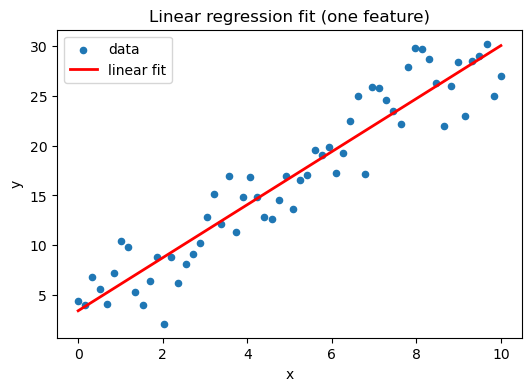

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(0)
x = np.linspace(0, 10, 60)
y = 2.5 * x + 4 + rng.normal(0, 3, x.size)     # true slope 2.5, intercept 4

lin = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"learned slope = {lin.coef_[0]:.2f}, intercept = {lin.intercept_:.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20, label="data")
plt.plot(x, lin.predict(x.reshape(-1, 1)), "r", lw=2, label="linear fit")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title("Linear regression fit (one feature)")
plt.show()

## Loss functions for regression

We measure error as the gap between truth $y_i$ and prediction $\hat{y}_i$:

- **Mean Squared Error (MSE, L2 loss)** —
  $\frac{1}{N}\sum (y_i-\hat{y}_i)^2$. Squares the error, so large mistakes are
  penalized heavily. Units are *squared*.
- **Mean Absolute Error (MAE, L1 loss)** —
  $\frac{1}{N}\sum |y_i-\hat{y}_i|$. Keeps the original units and is **less
  sensitive to outliers**.
- **Root Mean Squared Error (RMSE)** — $\sqrt{\text{MSE}}$. Popular because it
  preserves the units of the target.

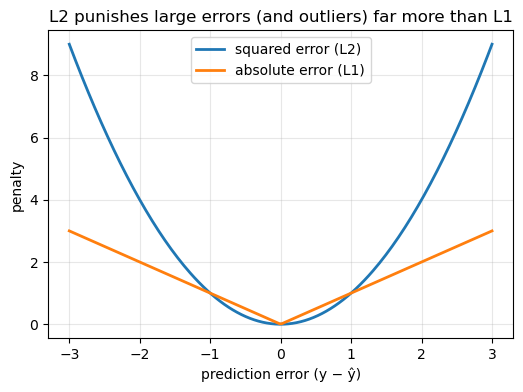

In [2]:
err = np.linspace(-3, 3, 200)
plt.figure(figsize=(6, 4))
plt.plot(err, err**2, lw=2, label="squared error (L2)")
plt.plot(err, np.abs(err), lw=2, label="absolute error (L1)")
plt.xlabel("prediction error (y − ŷ)"); plt.ylabel("penalty")
plt.title("L2 punishes large errors (and outliers) far more than L1")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Normal equation vs. gradient descent

Linear regression has a closed-form solution, the **normal equation**:

$$\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}$$

It's exact, but requires inverting an $m \times m$ matrix — prohibitive when
there are many features, and it needs $X^\top X$ to be invertible. **Gradient
descent** avoids the inversion, scales to large data sets that don't fit in
memory, and is what we use in practice for big problems.

## Polynomial regression, underfitting and overfitting

We can capture non-linear relationships by appending polynomial terms
($x^2, x^3, \dots$) to the feature vector and *still* solving it as linear
regression (scikit-learn's `PolynomialFeatures` does the appending).

Model complexity has to be tuned:

- Too simple (a straight line through curved data) → **underfitting**: poor on
  both training *and* test data.
- Too complex (a very high-degree polynomial) → **overfitting**: it memorizes
  the training noise and generalizes badly.

Below we fit degree 1, 4, and 15 to the same noisy quadratic.

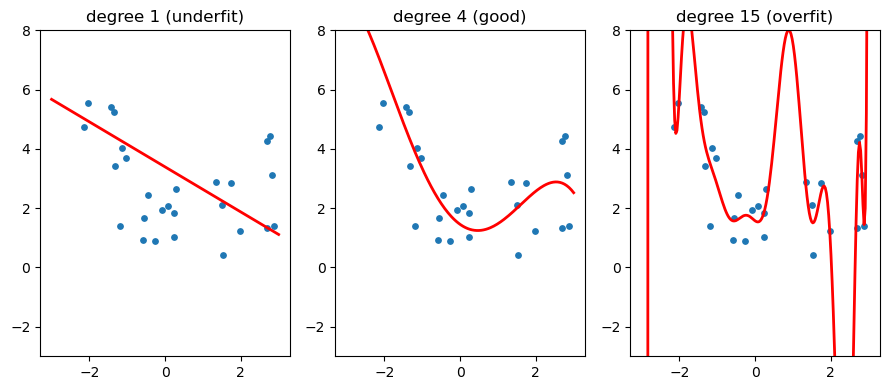

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(1)
xs = np.sort(rng.uniform(-3, 3, 30))
ys = 0.5 * xs**2 - xs + 2 + rng.normal(0, 1.5, xs.size)
grid = np.linspace(-3, 3, 200)

plt.figure(figsize=(9, 4))
for i, deg in enumerate([1, 4, 15]):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(xs.reshape(-1, 1), ys)
    plt.subplot(1, 3, i + 1)
    plt.scatter(xs, ys, s=15)
    plt.plot(grid, model.predict(grid.reshape(-1, 1)), "r", lw=2)
    plt.ylim(-3, 8)
    plt.title(f"degree {deg}" + (" (underfit)" if deg == 1 else " (overfit)" if deg == 15 else " (good)"))
plt.tight_layout()
plt.show()

## Benchmarking with $R^2$

**Step 1 — pick a metric** (MSE, RMSE, MAE...).

**Step 2 — report the coefficient of determination $R^2$**, the fraction of the
variance in $y$ that the model explains:

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

$R^2 = 1$ is perfect; $R^2 = 0$ is no better than predicting the mean; $R^2 < 0$
means the model does *worse* than the mean. (Note $R^2 \ne r$, the correlation
coefficient.)

**Step 3 — report on training, validation, and test sets separately.** The
**test** score estimates *generalization* — how the model will do on new,
unseen data. A high training score with a low test score is the signature of
overfitting.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# high-degree model to expose overfitting
X_ = xs.reshape(-1, 1)
Xtr, Xte, ytr, yte = train_test_split(X_, ys, test_size=0.4, random_state=0)
of = make_pipeline(PolynomialFeatures(15), LinearRegression()).fit(Xtr, ytr)

for name, Xs, ysub in [("train", Xtr, ytr), ("test", Xte, yte)]:
    pred = of.predict(Xs)
    print(f"{name:5s}  R^2 = {r2_score(ysub, pred):6.2f}   "
          f"RMSE = {np.sqrt(mean_squared_error(ysub, pred)):5.2f}")

train  R^2 =   0.98   RMSE =  0.38
test   R^2 = -2055712.30   RMSE = 2244.23


## Regularization: Ridge and Lasso

Regularization adds a penalty on the size of the weights to the loss, discouraging
the model from fitting noise:

- **Ridge regression (L2)** — penalizes $\sum w_j^2$. Shrinks all coefficients
  toward zero but keeps every feature.
- **Lasso regression (L1)** — penalizes $\sum |w_j|$. Can drive some coefficients
  *exactly* to zero, performing implicit **feature selection**.

The plot below fits Lasso to a problem with many mostly-irrelevant features and
increases the penalty strength $\alpha$: watch the coefficients collapse to zero
(sparse solution).

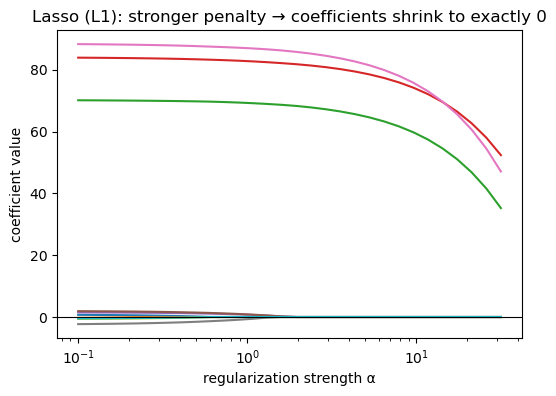

In [5]:
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression

Xr, yr = make_regression(n_samples=100, n_features=10, n_informative=3,
                         noise=10, random_state=0)
alphas = np.logspace(-1, 1.5, 30)
coefs = [Lasso(alpha=a, max_iter=10000).fit(Xr, yr).coef_ for a in alphas]

plt.figure(figsize=(6, 4))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("regularization strength α")
plt.ylabel("coefficient value")
plt.title("Lasso (L1): stronger penalty → coefficients shrink to exactly 0")
plt.axhline(0, color="k", lw=0.8)
plt.show()

## Summary

This page covered **supervised regression** — predicting a *continuous* target
from a set of input features, using the same predict-then-minimize-a-loss recipe
as classification.

- **Multiple linear regression** predicts a weighted sum of the features plus a
  bias, $\hat{y} = b + w_1 x_1 + \dots + w_m x_m = \mathbf{w}\cdot\mathbf{x} + b$.
  Each weight $w_j$ is the linear importance of feature $j$: how much the
  prediction changes per unit change in that feature.
- **Polynomial features** ($x^2, x^3, \dots$) let the *same* linear machinery
  fit non-linear curves — you expand the feature vector and still solve a linear
  problem.
- We fit the weights by **minimizing a loss** that measures how far predictions
  fall from the truth:
  - **MSE / L2** squares the errors, so it punishes large mistakes hard and is
    sensitive to outliers; it has a clean closed-form solution.
  - **MAE / L1** takes absolute errors, so it is more robust to outliers.
  - **RMSE** is the square root of MSE, reported to keep the error in the
    original units of the target.
- Linear regression can be solved exactly with the **normal equation**
  $\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}$, or iteratively with
  **gradient descent** when there are too many features to invert the matrix or
  the data don't fit in memory.
- **Model complexity must be tuned** between two failure modes: too simple
  **underfits** (poor on both training and test data), too complex **overfits**
  (memorizes training noise and generalizes badly). Always benchmark with
  $R^2$ — the fraction of variance the model explains — on a held-out **test**
  set, never on the training data.
- **Regularization** adds a penalty on the size of the weights to fight
  overfitting:
  - **Ridge (L2)** penalizes $\sum w_j^2$, shrinking all coefficients toward
    zero but keeping every feature.
  - **Lasso (L1)** penalizes $\sum |w_j|$ and can drive coefficients *exactly*
    to zero, performing implicit **feature selection**.

Next: [Decision Trees and Random Forests](treesforests.ipynb), which drop the
straight-line assumption entirely and partition the feature space into regions.